# Synthetic menu dataset analysis (Large Dataset Version)

**Optimized for datasets with 2,000+ samples** - reduces memory usage by:
- Sampling images instead of loading all
- Processing in batches for quality checks
- Limiting visualization grids

**Read this before trusting any number in this notebook.** Every crop here comes from the same handwriting-synthesis model. A test split that also comes from that model does **not** tell you how the fine-tuned OCR model will do on a real photographed menu — it tells you how well it learned this particular generator's stroke statistics.

What this notebook checks:
1. Basic composition (split sizes, field types, categories)
2. **Style leakage** — confirms the enforced style-disjoint split actually holds
3. **Vocabulary overlap** — reports how much val/test text appears in training text
4. Text length / character vocabulary coverage
5. Image quality — blank, tiny, or degenerate renders (sampled check)
6. Price format and style/bias diversity
7. Visual sample grid (small sample)
8. Summary and go/no-go recommendation

In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import gc  # Garbage collection for memory management

# Point this at your generated dataset directory
DATASET_DIR = Path("dataset_synth")

df = pd.read_csv(DATASET_DIR / "manifest.csv")
print(f"{len(df)} total crops")
print(f"Memory-optimized mode: {'ON' if len(df) > 1000 else 'OFF'}")
df.head()

4393 total crops
Memory-optimized mode: ON


,crop_path,text,split,field_type,style_id,bias,category,vocab_bucket
0,crops\header_00000.png,COFFEE,val,header,7,0.90,Coffee,train
1,crops\header_00001.png,COFFEE,test,header,3,0.70,Coffee,train
2,crops\header_00002.png,COFFEE,train,header,0,0.79,Coffee,train
3,crops\header_00003.png,COFFEE,train,header,11,0.94,Coffee,train
4,crops\header_00004.png,COFFEE,train,header,2,0.76,Coffee,train


## 1. Basic composition

In [2]:
print("Split sizes:")
print(df["split"].value_counts())
print()
print("By field type x split:")
print(df.groupby(["split", "field_type"]).size().unstack(fill_value=0))
print()
print("By category x split:")
print(df.groupby(["split", "category"]).size().unstack(fill_value=0))

Split sizes:
split
train    3073
test      673
val       647
Name: count, dtype: int64

By field type x split:
field_type  header  name  price
split                          
test            33   329    311
train          145  1487   1441
val             29   277    341

By category x split:
category  Breakfast  Coffee  Desserts  Juices & Smoothies  Pastries  Salads  \
split                                                                         
test             86      93        81                  54        86      52   
train           396     503       333                 275       401     279   
val              93     117        69                  62        88      60   

category  Sandwiches  Soft Drinks  Tea  
split                                   
test              75           56   90  
train            344          202  340  
val               64           41   53  


## 2. Style leakage check

This should show **zero overlap** — the generation script enforces a style-disjoint split.

In [3]:
train_styles = set(df[df.split == "train"].style_id)
val_styles = set(df[df.split == "val"].style_id)
test_styles = set(df[df.split == "test"].style_id)

print("train styles:", sorted(train_styles))
print("val styles:  ", sorted(val_styles))
print("test styles: ", sorted(test_styles))

overlap_tv = train_styles & val_styles
overlap_tt = train_styles & test_styles
overlap_vt = val_styles & test_styles

ok = not (overlap_tv or overlap_tt or overlap_vt)
print(f"\n{'PASS' if ok else 'FAIL'}: style overlap train/val={overlap_tv} train/test={overlap_tt} val/test={overlap_vt}")

train styles: [0, 1, 2, 4, 5, 6, 8, 9, 11]
val styles:   [7, 12]
test styles:  [3, 10]

PASS: style overlap train/val=set() train/test=set() val/test=set()


## 3. Vocabulary overlap (reported, not enforced)

In [4]:
train_texts = set(df[df.split == "train"].text)
val_texts = set(df[df.split == "val"].text)
test_texts = set(df[df.split == "test"].text)

val_overlap = val_texts & train_texts
test_overlap = test_texts & train_texts

print(f"val:  {len(val_overlap)}/{len(val_texts)} unique texts also appear verbatim in train ({len(val_overlap)/max(len(val_texts),1):.0%})")
print(f"test: {len(test_overlap)}/{len(test_texts)} unique texts also appear verbatim in train ({len(test_overlap)/max(len(test_texts),1):.0%})")
print()
print("Genuinely unseen-text val examples:", list(val_texts - train_texts)[:10])
print("Genuinely unseen-text test examples:", list(test_texts - train_texts)[:10])
print()
print("vocab_bucket column cross-check (item names reserved for val/test):")
print(df.groupby(["split", "vocab_bucket"]).size().unstack(fill_value=0))

val:  179/179 unique texts also appear verbatim in train (100%)
test: 181/181 unique texts also appear verbatim in train (100%)

Genuinely unseen-text val examples: []
Genuinely unseen-text test examples: []

vocab_bucket column cross-check (item names reserved for val/test):
vocab_bucket  test  train  val
split                         
test            85    480  108
train          431   2225  417
val             82    492   73


## 4. Text length and character coverage

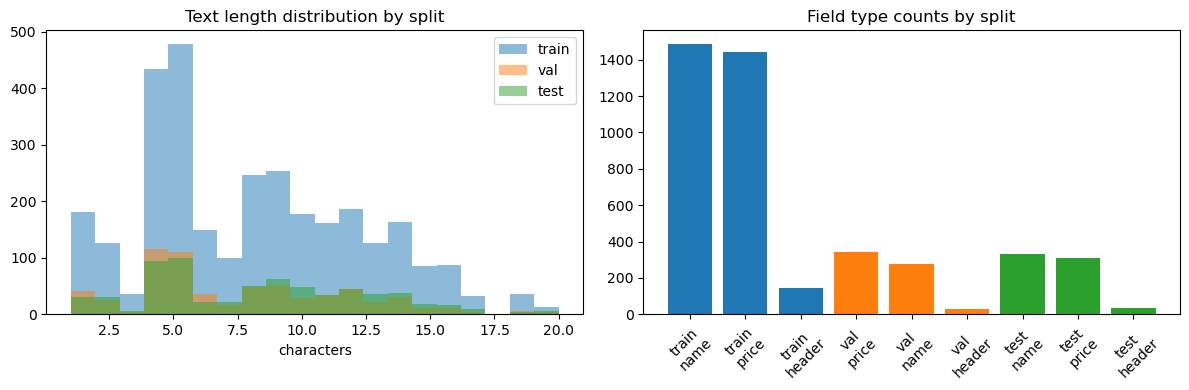

Characters in val but never in train: none
Characters in test but never in train: none


In [5]:
df["text_len"] = df["text"].str.len()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for split in ["train", "val", "test"]:
    subset = df[df.split == split]["text_len"]
    ax[0].hist(subset, bins=20, alpha=0.5, label=split)
ax[0].set_title("Text length distribution by split")
ax[0].set_xlabel("characters")
ax[0].legend()

for split in ["train", "val", "test"]:
    subset = df[df.split == split]["field_type"].value_counts()
    ax[1].bar([f"{split}\n{ft}" for ft in subset.index], subset.values)
ax[1].set_title("Field type counts by split")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

train_chars = set("".join(df[df.split == "train"].text))
val_chars = set("".join(df[df.split == "val"].text))
test_chars = set("".join(df[df.split == "test"].text))

oov_val = val_chars - train_chars
oov_test = test_chars - train_chars
print(f"Characters in val but never in train: {oov_val if oov_val else 'none'}")
print(f"Characters in test but never in train: {oov_test if oov_test else 'none'}")

## 5. Image quality: blank, tiny, or degenerate crops

**For large datasets:** Samples 500 random images instead of checking all.

Checking 500 images (sampled from 4393 total)...
  Checked 0/500...
  Checked 100/500...
  Checked 200/500...
  Checked 300/500...
  Checked 400/500...

0 problem images out of 500 checked (0.0%)
Note: Extrapolating to full dataset → ~0 total issues estimated


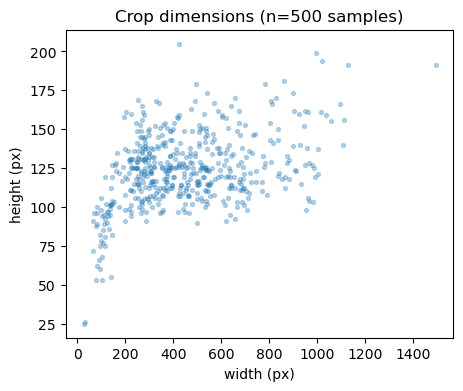

In [12]:
# Sample images if dataset is large to avoid memory issues
SAMPLE_SIZE = min(500, len(df))
df_sample = df.sample(SAMPLE_SIZE, random_state=42) if len(df) > 500 else df

print(f"Checking {len(df_sample)} images (sampled from {len(df)} total)...")

issues = []
sizes = []

for idx, (_, row) in enumerate(df_sample.iterrows()):
    if idx % 100 == 0:
        print(f"  Checked {idx}/{len(df_sample)}...")
        gc.collect()  # Free memory periodically
    
    img_path = DATASET_DIR / row["crop_path"]
    img = cv2.imread(str(img_path))
    
    if img is None:
        issues.append((row["crop_path"], "unreadable"))
        continue
    
    h, w = img.shape[:2]
    sizes.append((w, h))
    
    if img.std() < 5:
        issues.append((row["crop_path"], "near-blank (very low pixel variance)"))
    if h < 10 or w < 10:
        issues.append((row["crop_path"], f"tiny image {w}x{h}"))
    
    del img  # Free memory immediately

gc.collect()

print(f"\n{len(issues)} problem images out of {len(df_sample)} checked ({len(issues)/len(df_sample):.1%})")
if len(df) > len(df_sample):
    print(f"Note: Extrapolating to full dataset → ~{int(len(issues) * len(df) / len(df_sample))} total issues estimated")

for path, reason in issues[:20]:
    print(" ", path, "-", reason)
if len(issues) > 20:
    print(f"  ... and {len(issues) - 20} more")

if sizes:
    sizes = np.array(sizes)
    plt.figure(figsize=(5, 4))
    plt.scatter(sizes[:, 0], sizes[:, 1], alpha=0.3, s=8)
    plt.xlabel("width (px)")
    plt.ylabel("height (px)")
    plt.title(f"Crop dimensions (n={len(sizes)} samples)")
    plt.show()

## 6. Price format and style/bias diversity

Price format distribution:
format
dot_2dp      0.308
dot_3dp      0.264
integer      0.209
comma_2dp    0.187
other        0.033
Name: proportion, dtype: float64

Prices with a trailing currency mark: 16.5%

Style id distribution (want this roughly even, not dominated by one id):
style_id
0     327
1     324
2     349
3     341
4     333
5     352
6     359
7     323
8     323
9     374
10    332
11    332
12    324
Name: count, dtype: int64



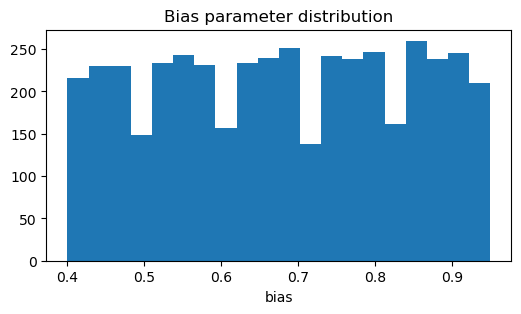

In [13]:
import re

price_rows = df[df.field_type == "price"].copy()

def price_format(text):
    if re.search(r"\d,\d{2}\b", text):
        return "comma_2dp"
    if re.search(r"\d\.\d{3}\b", text):
        return "dot_3dp"
    if re.search(r"\d\.\d{2}\b", text):
        return "dot_2dp"
    if re.search(r"^\d+$", text.strip()):
        return "integer"
    return "other"

price_rows["format"] = price_rows["text"].apply(price_format)
print("Price format distribution:")
print(price_rows["format"].value_counts(normalize=True).round(3))
print()

has_currency_letters = price_rows["text"].str.contains(r"[A-Za-z\u20ac]", regex=True)
print(f"Prices with a trailing currency mark: {has_currency_letters.mean():.1%}")
print()

print("Style id distribution (want this roughly even, not dominated by one id):")
print(df["style_id"].value_counts().sort_index())
print()

plt.figure(figsize=(6, 3))
plt.hist(df["bias"], bins=20)
plt.title("Bias parameter distribution")
plt.xlabel("bias")
plt.show()

## 7. Visual sample grid across splits

**Memory-optimized:** Shows only 8 samples per split instead of 12.

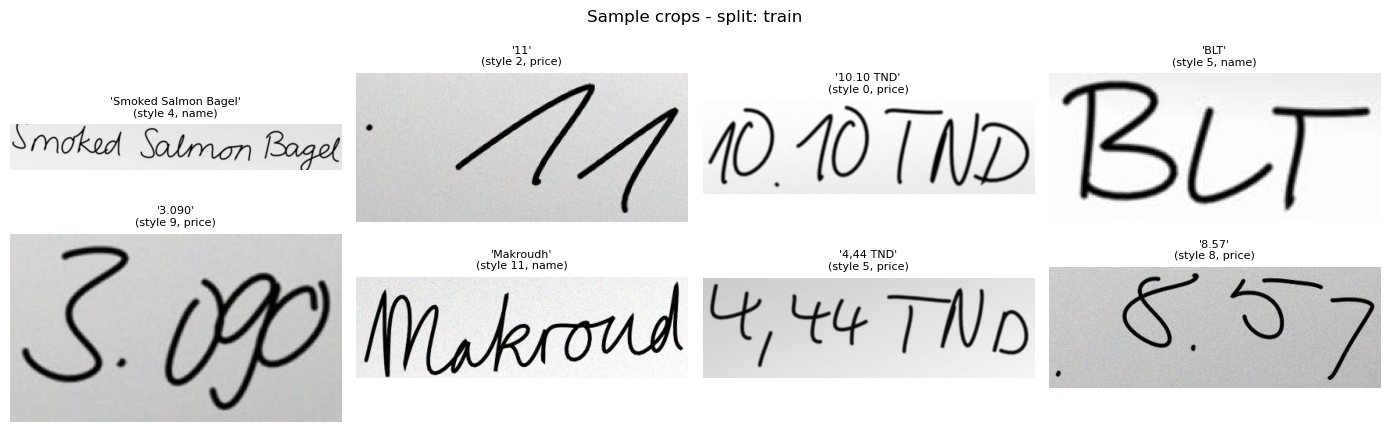

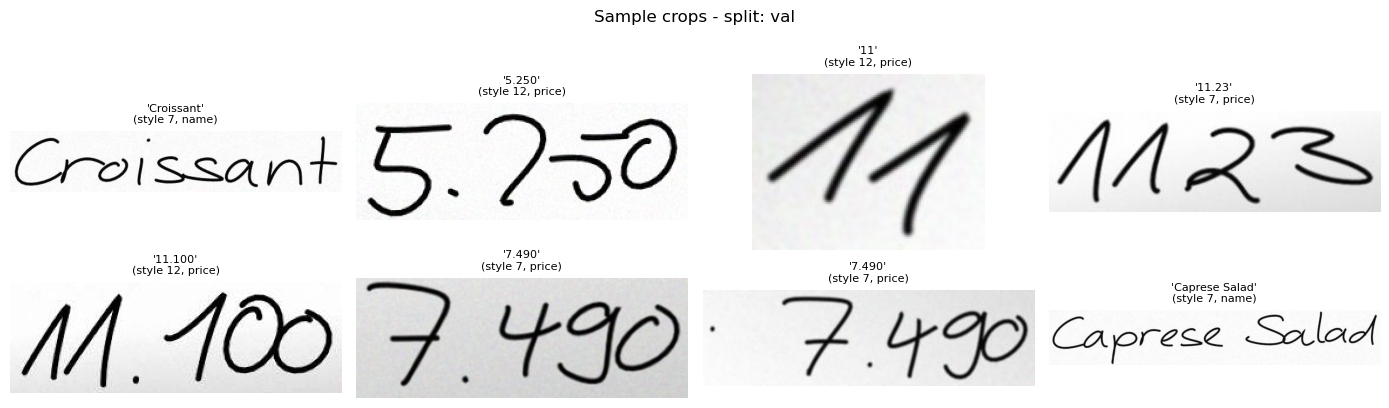

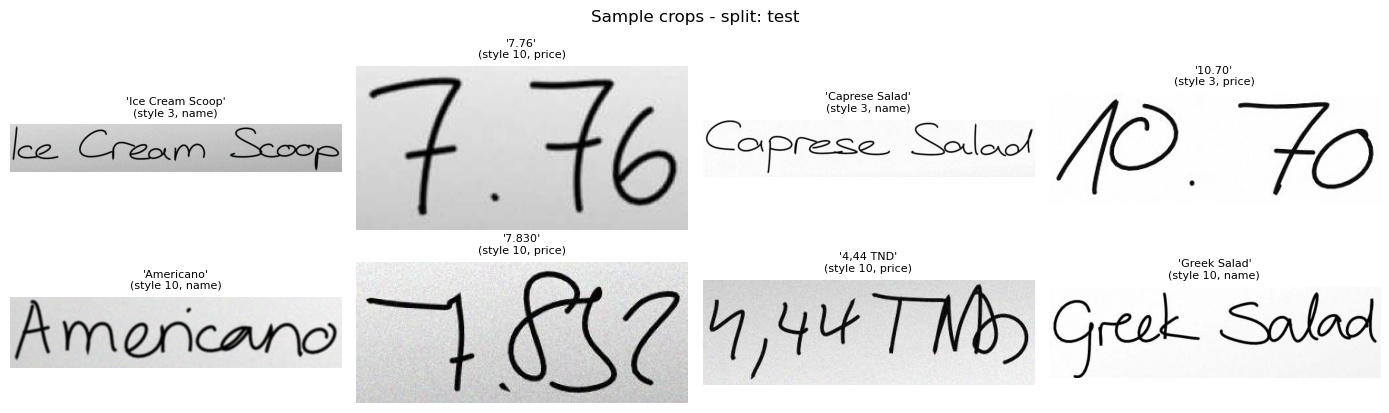

In [14]:
def show_grid(split, n=8, seed=0):
    """Show sample images. Limited to 8 for large datasets."""
    subset = df[df.split == split].sample(min(n, len(df[df.split == split])), random_state=seed)
    cols = 4
    rows = (len(subset) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 2.2 * rows))
    axes = np.array(axes).reshape(-1)
    
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = cv2.imread(str(DATASET_DIR / row["crop_path"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{row['text']!r}\n(style {row['style_id']}, {row['field_type']})", fontsize=8)
        ax.axis("off")
        del img  # Free memory
    
    for ax in axes[len(subset):]:
        ax.axis("off")
    
    fig.suptitle(f"Sample crops - split: {split}")
    plt.tight_layout()
    plt.show()
    
    gc.collect()  # Force garbage collection

for split in ["train", "val", "test"]:
    show_grid(split)

## 8. Summary and go/no-go before training

In [15]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total crops: {len(df)}")
print(f"Split sizes: {dict(df['split'].value_counts())}")
print(f"Style leakage across splits: {'NONE (good)' if ok else 'FOUND - fix before training'}")
print(f"Val text also seen in train: {len(val_overlap)/max(len(val_texts),1):.0%}")
print(f"Test text also seen in train: {len(test_overlap)/max(len(test_texts),1):.0%}")
print(f"OOV characters (val): {oov_val if oov_val else 'none'}")
print(f"OOV characters (test): {oov_test if oov_test else 'none'}")
print(f"Image quality issues (sampled): {len(issues)}/{len(df_sample)} ({len(issues)/len(df_sample):.1%})")
print()
print("Read this as: is the dataset internally sound (no leakage, no OOV\n"
      "chars, no broken images, reasonable diversity)? If all checks above\n"
      "look clean, it's reasonable to proceed to training.\n\n"
      "It does NOT tell you the model will work on real photographed\n"
      "menus - only real photos can tell you that. Keep that caveat in\n"
      "mind when reading whatever CER/WER numbers training produces.")

# Final memory cleanup
gc.collect()
print("\n✓ Notebook complete. Memory released.")

DATASET SUMMARY
Total crops: 4393
Split sizes: {'train': np.int64(3073), 'test': np.int64(673), 'val': np.int64(647)}
Style leakage across splits: NONE (good)
Val text also seen in train: 100%
Test text also seen in train: 100%
OOV characters (val): none
OOV characters (test): none
Image quality issues (sampled): 0/500 (0.0%)

Read this as: is the dataset internally sound (no leakage, no OOV
chars, no broken images, reasonable diversity)? If all checks above
look clean, it's reasonable to proceed to training.

It does NOT tell you the model will work on real photographed
menus - only real photos can tell you that. Keep that caveat in
mind when reading whatever CER/WER numbers training produces.

✓ Notebook complete. Memory released.
